Confusion Matrix:
 [[22442  1138]
 [  131 20845]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97     23580
           1       0.95      0.99      0.97     20976

    accuracy                           0.97     44556
   macro avg       0.97      0.97      0.97     44556
weighted avg       0.97      0.97      0.97     44556

Accuracy: 0.9715


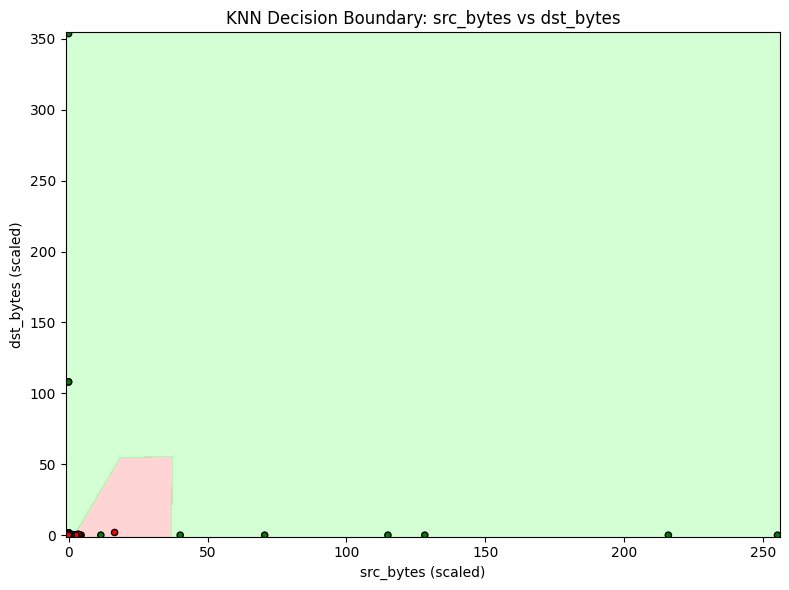

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# === 1. Load the NSL-KDD dataset ===
df_train = pd.read_csv("nslkdd/kdd_train.csv", header=0, low_memory=False)
df_test = pd.read_csv("nslkdd/kdd_test.csv", header=0, low_memory=False)

# === 2. Set column names ===
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
    'count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label'
]
df_train.columns = column_names
df_test.columns = column_names

# === 3. Combine and preprocess ===
df = pd.concat([df_train, df_test])
df = pd.get_dummies(df, columns=['protocol_type', 'service', 'flag'])
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# === 4. Select 2 features for visualization ===
X = df[['src_bytes', 'dst_bytes']]
y = df['label']

# === 5. Standardize features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 6. Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# === 7. Train KNN model ===
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# === 8. Evaluate model ===
y_pred = knn.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# === 9. Visualize Decision Boundary ===
h = 0.1  # step size for mesh
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA"])
cmap_bold = ["red", "green"]

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=ListedColormap(cmap_bold), s=20, edgecolor='k')
plt.xlabel("src_bytes (scaled)")
plt.ylabel("dst_bytes (scaled)")
plt.title("KNN Decision Boundary: src_bytes vs dst_bytes")
plt.tight_layout()
plt.show()
